# Feature Validation & Data-Quality Exclusion Analysis

Two-phase notebook. **Phase 1 (this iteration)** analyses the MMPose and TrackNet detection failure data Ari pushed in `bst_x/validation_scripts/zeroed_frames_analysis_outputs/` and turns it into an exclusion proposal for Phase 2 retraining. **Phase 2 (pending MMPose collation completion on engelbart)** adds keypoint shape/range checks and visual overlay validation on the collated feature arrays.

The underlying concern, from Ari's Apr 16 analysis: when MMPose can't detect a player, the transformer receives zeros for joints, court positions, **and** shuttle — with no attention masking. About 7% of frames are affected overall, but it's concentrated: 25% of smash clips have over half of their ±10 hit-frame zone zeroed. That's a ceiling on model performance we should quantify before Phase 2 locks in a baseline.

My Apr 16 reply to Ari proposed **filter-per-window-not-per-clip**, scored on (a) valid-frame %, (b) longest contiguous zero gap, (c) gap position relative to the anchor frame. Ari's analysis is at clip level; this notebook pushes it to the window level and projects the impact onto `shuttleset_splits_v2.csv`.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# Paths (adjust if running outside notebooks/)
ANALYSIS_DIR = Path('../src/bst_x/validation_scripts/zeroed_frames_analysis_outputs')
REVISED_SPLITS = Path('shuttleset_splits_v2.csv')

# Primary input: Ari's text summary of the zeroed-frames analysis
ANALYSIS_TXT = ANALYSIS_DIR / 'analysis_merged25_20260416_1611.txt'

print(f"Analysis output dir: {ANALYSIS_DIR}")
print(f"Exists: {ANALYSIS_DIR.exists()}")
print(f"Revised splits:       {REVISED_SPLITS}")
print(f"Exists: {REVISED_SPLITS.exists()}")


Analysis output dir: ..\src\bst_x\validation_scripts\zeroed_frames_analysis_outputs
Exists: True
Revised splits:       shuttleset_splits_v2.csv
Exists: True


## 2. Global Failure Rates (from Ari's analysis)

Pulled directly from `analysis_merged25_20260416_1611.txt`. Hard-coded here so the notebook is reproducible without re-running Ari's scan script.

In [2]:
# Top-line numbers from analysis_merged25_20260416_1611.txt
TOTAL_CLIPS              = 33_481
TOTAL_FRAMES             = 1_775_308
MMPOSE_FAILED_FRAMES     = 121_852           # 6.86% of all frames
UNKNOWN_CLIPS            = 1_330             # the 'rubbish bin' class
CLIPS_WITH_SHUTTLE       = 32_151

# Per-split MMPose failure (merged_25 baseline splits, NOT our revised splits)
baseline_split_mmpose = pd.DataFrame([
    {'split': 'train', 'clips': 25_741, 'total_frames': 1_332_217, 'failed_frames': 87_249},
    {'split': 'val',   'clips':  4_241, 'total_frames':   244_097, 'failed_frames': 19_053},
    {'split': 'test',  'clips':  3_499, 'total_frames':   198_994, 'failed_frames': 15_550},
])
baseline_split_mmpose['fail_rate'] = (
    baseline_split_mmpose['failed_frames'] / baseline_split_mmpose['total_frames'] * 100
).round(2)

print("MMPose frame-level failure by split (BST baseline splits):")
print(f"{'Split':<6} {'Clips':>7} {'Frames':>12} {'Failed':>10} {'Rate':>7}")
print('-' * 48)
for _, r in baseline_split_mmpose.iterrows():
    print(f"{r['split']:<6} {r['clips']:>7,} {r['total_frames']:>12,} {r['failed_frames']:>10,} {r['fail_rate']:>6.2f}%")

print(f"\nOverall: {MMPOSE_FAILED_FRAMES:,} / {TOTAL_FRAMES:,} = {MMPOSE_FAILED_FRAMES/TOTAL_FRAMES*100:.2f}%")


MMPose frame-level failure by split (BST baseline splits):
Split    Clips       Frames     Failed    Rate
------------------------------------------------
train   25,741    1,332,217     87,249   6.55%
val      4,241      244,097     19,053   7.81%
test     3,499      198,994     15,550   7.81%

Overall: 121,852 / 1,775,308 = 6.86%


### Observations: Global MMPose Failure
- Train fails at 6.55% vs val/test both at 7.81% — val/test are substantially dirtier than train
- That ~1.3pp gap is the kind of thing that can drive apparent generalisation loss independent of model quality — the held-out data is genuinely harder to estimate poses on
- Overall 6.86% aggregate hides bigger class-level problems (section 3)

## 3. Failure Rate by Stroke Type

In [3]:
# Per-stroke MMPose fail rates (from Ari's analysis, merged_25 taxonomy)
stroke_mmpose = pd.DataFrame([
    ('unknown',              1330, 29_319,  55_465),
    ('smash',                3921, 24_442, 199_717),
    ('long_service',          359,  2_270,  19_838),
    ('clear',                2661, 13_722, 186_248),
    ('return_net',           3374,  8_592, 144_218),
    ('lob',                  5157, 17_225, 324_227),
    ('drop',                 3177,  9_077, 191_224),
    ('short_service',        1858,  2_784,  73_588),
    ('push',                 2652,  4_327, 140_442),
    ('net_shot',             5824,  7_399, 303_086),
    ('cross_court_net_shot', 1226,  1_244,  61_552),
    ('rush',                  471,    321,  16_586),
    ('drive',                1471,  1_130,  59_117),
], columns=['stroke', 'clips', 'failed', 'total'])
stroke_mmpose['fail_rate'] = (stroke_mmpose['failed'] / stroke_mmpose['total'] * 100).round(2)

# Per-stroke TrackNet (shuttle) miss rates within ±10 frames of hit
stroke_shuttle_hit = pd.DataFrame([
    ('long_service',            791,   7_528),
    ('clear',                 3_296,  55_854),
    ('rush',                    293,   9_837),
    ('lob',                   2_818, 107_920),
    ('smash',                 1_489,  82_117),
    ('short_service',           445,  38_999),
    ('drive',                   261,  30_608),
    ('return_net',              379,  70_155),
    ('drop',                    344,  66_598),
    ('net_shot',                312, 121_867),
    ('push',                    127,  55_466),
    ('cross_court_net_shot',     29,  25_688),
], columns=['stroke', 'missed_hit_zone', 'total_hit_zone'])
stroke_shuttle_hit['miss_rate'] = (
    stroke_shuttle_hit['missed_hit_zone'] / stroke_shuttle_hit['total_hit_zone'] * 100
).round(2)

# Joined view (exclude 'unknown' which is a rubbish-bin class)
stroke_quality = stroke_mmpose[stroke_mmpose['stroke'] != 'unknown'].merge(
    stroke_shuttle_hit, on='stroke', how='left'
).sort_values('fail_rate', ascending=False)

print("Per-stroke data quality (sorted by MMPose fail rate):")
print(f"{'Stroke':<22} {'Clips':>6} {'MMPose%':>9} {'Shuttle(hit)%':>15}")
print('-' * 56)
for _, r in stroke_quality.iterrows():
    print(f"{r['stroke']:<22} {r['clips']:>6,} {r['fail_rate']:>8.2f}% {r['miss_rate']:>14.2f}%")


Per-stroke data quality (sorted by MMPose fail rate):
Stroke                  Clips   MMPose%   Shuttle(hit)%
--------------------------------------------------------
smash                   3,921    12.24%           1.81%
long_service              359    11.44%          10.51%
clear                   2,661     7.37%           5.90%
return_net              3,374     5.96%           0.54%
lob                     5,157     5.31%           2.61%
drop                    3,177     4.75%           0.52%
short_service           1,858     3.78%           1.14%
push                    2,652     3.08%           0.23%
net_shot                5,824     2.44%           0.26%
cross_court_net_shot    1,226     2.02%           0.11%
rush                      471     1.94%           2.98%
drive                   1,471     1.91%           0.85%


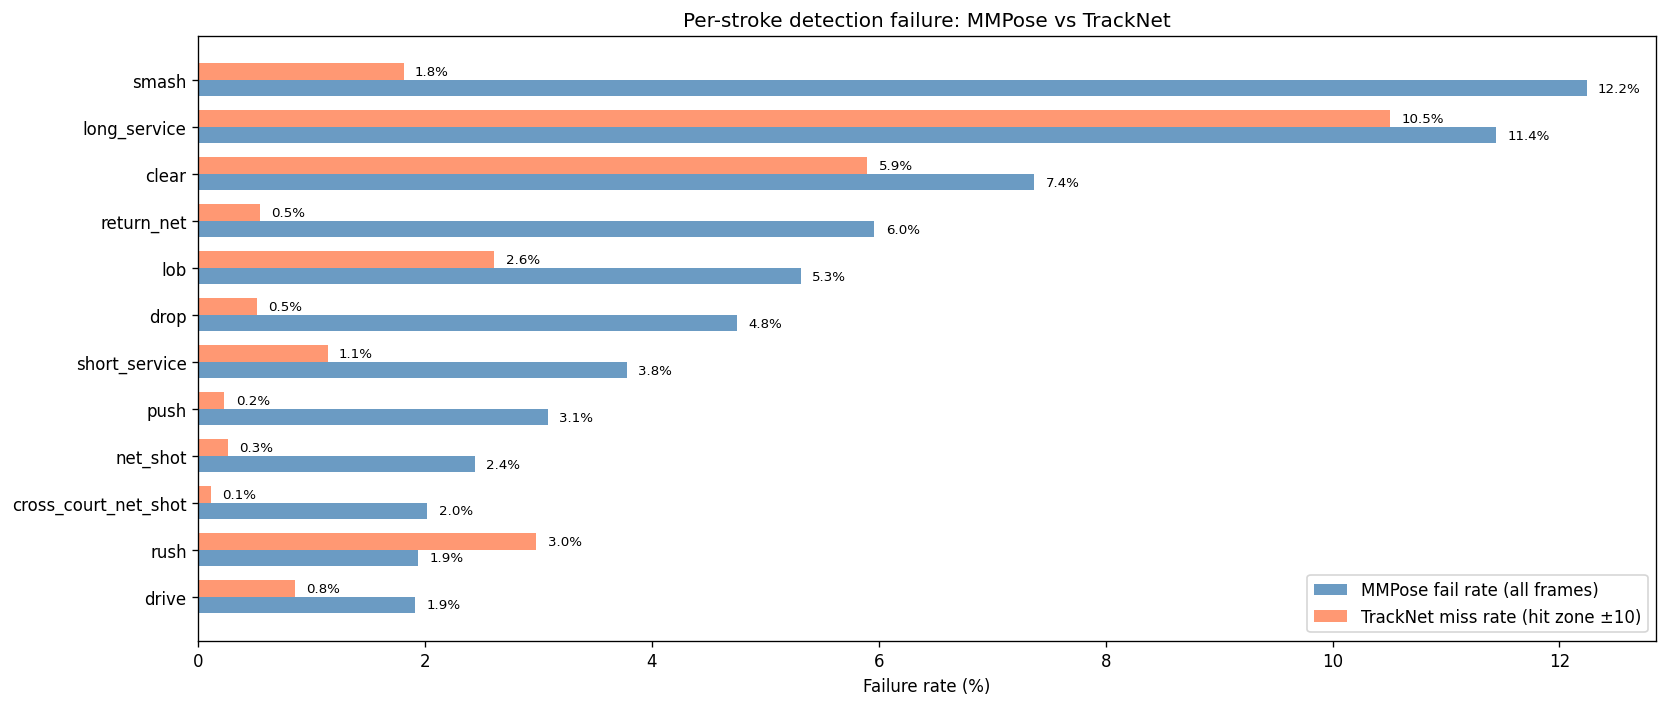

In [4]:
# Visualise: MMPose vs shuttle-miss by stroke (excluding unknown)
fig, ax = plt.subplots(figsize=(14, 6))
sq = stroke_quality.sort_values('fail_rate', ascending=True).reset_index(drop=True)
x = np.arange(len(sq))
w = 0.35

ax.barh(x - w/2, sq['fail_rate'],   w, color='steelblue', alpha=0.8, label='MMPose fail rate (all frames)')
ax.barh(x + w/2, sq['miss_rate'],   w, color='coral',     alpha=0.8, label='TrackNet miss rate (hit zone ±10)')
ax.set_yticks(x); ax.set_yticklabels(sq['stroke'])
ax.set_xlabel('Failure rate (%)')
ax.set_title('Per-stroke detection failure: MMPose vs TrackNet')
ax.legend(loc='lower right')
for i, row in sq.iterrows():
    ax.text(row['fail_rate'] + 0.1, i - w/2, f"{row['fail_rate']:.1f}%", va='center', fontsize=8)
    ax.text(row['miss_rate'] + 0.1, i + w/2, f"{row['miss_rate']:.1f}%", va='center', fontsize=8)
plt.tight_layout()
plt.show()


### Observations: Per-stroke Failure Correlation with Shot Type
**Answering the Apr 14 question** — *does TrackNet dropout correlate with shot type?*

- Yes, both detectors fail more on fast / occlusion-heavy strokes, but the failure modes are different
- MMPose order: smash (12.2%) > long_service (11.4%) > clear (7.4%) > return_net (6.0%). Smash body pose is hardest because player motion blurs at contact
- TrackNet hit-zone miss order: long_service (10.5%) > clear (5.9%) > rush (3.0%) > lob (2.6%) > smash (1.8%). Service is hardest because the shuttle is near-stationary at serve start and TrackNet was trained on rallies
- **Smash is the canary class** — high MMPose failure + moderate shuttle miss means any filter that cuts 50%+ bad clips will disproportionately cut smashes. The smash distribution shift is a real risk we need to measure
- `unknown` class runs at 52.86% MMPose fail rate — it's the rubbish bin by definition, not a real stroke. Should be excluded from training regardless of threshold choice

## 4. Hit-Zone Failure (Where It Really Matters)

The ±10-frame window around the contact event is what the model is really classifying on. A clip with dead middle 30 frames but a clean contact zone is still usable; a clip with a clean start/end but a dead hit zone is not.

In [5]:
# From 'MMPose failure near hit frames' section
hit_zone_mmpose = pd.DataFrame([
    {'zone': 'near hit (±10)',   'clips': 32_146, 'failed': 40_242, 'total': 672_789},
    {'zone': 'away from hit',     'clips': 32_146, 'failed': 52_283, 'total': 1_046_962},
])
hit_zone_mmpose['rate'] = (hit_zone_mmpose['failed'] / hit_zone_mmpose['total'] * 100).round(2)

hit_zone_shuttle = pd.DataFrame([
    {'zone': 'near hit (±10)', 'clips': 32_146, 'missed': 10_584, 'total':   672_637},
    {'zone': 'away from hit',   'clips': 32_146, 'missed': 98_381, 'total': 1_046_918},
])
hit_zone_shuttle['rate'] = (hit_zone_shuttle['missed'] / hit_zone_shuttle['total'] * 100).round(2)

print("MMPose fail rate by zone:")
for _, r in hit_zone_mmpose.iterrows():
    print(f"  {r['zone']:<20} {r['failed']:>7,} / {r['total']:>9,}  = {r['rate']:>5.2f}%")
print()
print("TrackNet miss rate by zone (32,146 matched clips):")
for _, r in hit_zone_shuttle.iterrows():
    print(f"  {r['zone']:<20} {r['missed']:>7,} / {r['total']:>9,}  = {r['rate']:>5.2f}%")

# MMPose hit-zone tiers
hit_tiers_mmpose = pd.DataFrame([
    {'threshold': '100% zeroed',  'clips':  138, 'pct': 0.4},
    {'threshold': '>90% zeroed',  'clips':  342, 'pct': 1.1},
    {'threshold': '>75% zeroed',  'clips':  770, 'pct': 2.4},
    {'threshold': '>50% zeroed',  'clips': 1713, 'pct': 5.3},
    {'threshold': 'any zeroed',   'clips': 4465, 'pct': 13.9},
])
print("\nMMPose hit-zone tiers (of 32,146 matched clips):")
for _, r in hit_tiers_mmpose.iterrows():
    print(f"  {r['threshold']:<15} {r['clips']:>5,}  ({r['pct']}%)")


MMPose fail rate by zone:
  near hit (±10)        40,242 /   672,789  =  5.98%
  away from hit         52,283 / 1,046,962  =  4.99%

TrackNet miss rate by zone (32,146 matched clips):
  near hit (±10)        10,584 /   672,637  =  1.57%
  away from hit         98,381 / 1,046,918  =  9.40%

MMPose hit-zone tiers (of 32,146 matched clips):
  100% zeroed       138  (0.4%)
  >90% zeroed       342  (1.1%)
  >75% zeroed       770  (2.4%)
  >50% zeroed     1,713  (5.3%)
  any zeroed      4,465  (13.9%)


### Observations: Hit-Zone Concentration
- MMPose is marginally *worse* in the hit zone (5.98% vs 4.99% away) — motion blur at contact hurts pose estimation
- TrackNet is dramatically *better* in the hit zone (1.57% vs 9.40% away) — the shuttle is easier to detect when it's near the racket than when it's travelling fast mid-flight
- **138 clips (0.4%) have 100% zeroed hit zones** — the model is being trained on pure noise for these. They should be excluded regardless of threshold discussion
- 1,713 clips (5.3%) have over half their hit zone zeroed — these are the main target for filtering

## 5. Combined (MMPose OR Shuttle) Failure in Hit Zone

The headline chart from Ari's analysis. A clip is "bad in hit zone" if either MMPose *or* TrackNet fails for more than 50% of the ±10 frame window. The class × split heatmap shows where the damage is concentrated.

In [6]:
# From the 'Combined hit-zone clip quality by class x split' table
combined = pd.DataFrame([
    ('smash',                'train', 2951, 742, 25.1),
    ('smash',                'test',   452, 101, 22.3),
    ('smash',                'val',    515, 109, 21.2),
    ('clear',                'test',   379,  47, 12.4),
    ('drop',                 'test',   315,  39, 12.4),
    ('clear',                'val',    411,  44, 10.7),
    ('clear',                'train', 1871, 174,  9.3),
    ('long_service',         'test',   102,   9,  8.8),
    ('long_service',         'val',     46,   4,  8.7),
    ('drop',                 'train', 2438, 210,  8.6),
    ('long_service',         'train',  211,  15,  7.1),
    ('return_net',           'train', 2636, 162,  6.1),
    ('drop',                 'val',    424,  26,  6.1),
    ('return_net',           'val',    386,  19,  4.9),
    ('return_net',           'test',   350,  17,  4.9),
    ('rush',                 'train',  358,  17,  4.7),
    ('cross_court_net_shot', 'test',   104,   4,  3.8),
    ('short_service',        'train', 1496,  53,  3.5),
], columns=['stroke', 'split', 'clips', 'bad_50', 'pct'])

# Pivot for heatmap-style printing
pivot = combined.pivot(index='stroke', columns='split', values='pct').fillna(0)
pivot = pivot.reindex(['smash', 'clear', 'drop', 'long_service', 'return_net', 'rush',
                       'cross_court_net_shot', 'short_service'])

print("% of clips with >50% bad (MMPose OR shuttle) frames in hit zone:")
print(f"{'Stroke':<22} {'train':>8} {'val':>8} {'test':>8}")
print('-' * 50)
for stroke, row in pivot.iterrows():
    train_v = row.get('train', 0)
    val_v   = row.get('val',   0)
    test_v  = row.get('test',  0)
    print(f"{stroke:<22} {train_v:>7.1f}% {val_v:>7.1f}% {test_v:>7.1f}%")


% of clips with >50% bad (MMPose OR shuttle) frames in hit zone:
Stroke                    train      val     test
--------------------------------------------------
smash                     25.1%    21.2%    22.3%
clear                      9.3%    10.7%    12.4%
drop                       8.6%     6.1%    12.4%
long_service               7.1%     8.7%     8.8%
return_net                 6.1%     4.9%     4.9%
rush                       4.7%     0.0%     0.0%
cross_court_net_shot       0.0%     0.0%     3.8%
short_service              3.5%     0.0%     0.0%


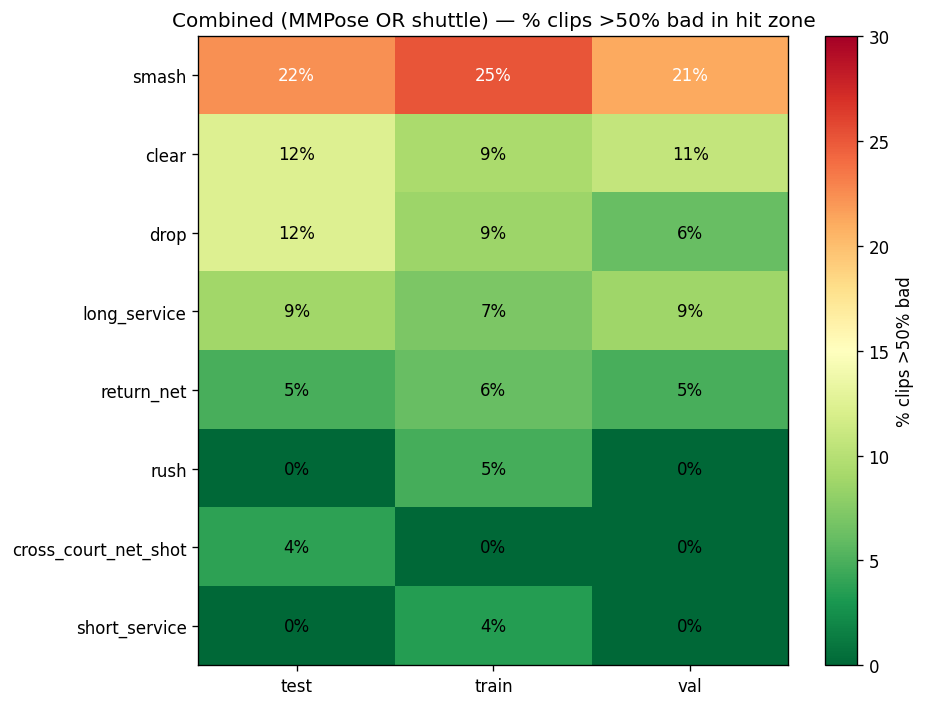

In [7]:
# Visualise as a proper heatmap
fig, ax = plt.subplots(figsize=(8, 6))
data = pivot.reindex(['smash', 'clear', 'drop', 'long_service', 'return_net', 'rush',
                      'cross_court_net_shot', 'short_service']).values
im = ax.imshow(data, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=30)
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)));    ax.set_yticklabels(pivot.index)
ax.set_title('Combined (MMPose OR shuttle) — % clips >50% bad in hit zone')
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        txt_color = 'white' if data[i, j] > 15 else 'black'
        ax.text(j, i, f'{data[i, j]:.0f}%', ha='center', va='center', color=txt_color, fontsize=10)
plt.colorbar(im, ax=ax, label='% clips >50% bad')
plt.tight_layout()
plt.show()


### Observations: Class × Split Damage
- **Smash is by far the most compromised class**: 21–25% of clips are >50% bad in hit zone across all three splits. This is the 25% figure Ari kept flagging in Slack
- Clear, drop, and long_service are the second tier (7–12% bad)
- Classes with small absolute clip counts (long_service ~46 in val) are also the most volatile — a handful of excluded clips can swing the per-class proportion substantially
- The damage is roughly consistent across train/val/test for most classes, meaning exclusion won't cause a distribution shift between splits. The exception is clear/drop on test (12%) vs train (9%) — test is slightly dirtier

## 6. Flaw Annotation vs. Pose Failure

Ari cross-referenced ShuttleSet's `flaw=1.0` annotation against the MMPose failure data. The question: are flaw-annotated shots also the ones MMPose struggles with?

In [8]:
flaw_vs_pose = pd.DataFrame([
    {'group': 'flaw=1.0',     'clips':     33, 'failed':    432, 'total':     1_281, 'rate': 33.72},
    {'group': 'non-flaw',     'clips': 32_118, 'failed': 92_101, 'total': 1_718_562, 'rate':  5.36},
])

print("Flaw annotation vs. MMPose pose failure:")
print(f"{'Group':<12} {'Clips':>7} {'Failed':>8} / {'Total':<10} {'Rate':>7}")
print('-' * 50)
for _, r in flaw_vs_pose.iterrows():
    print(f"{r['group']:<12} {r['clips']:>7,} {r['failed']:>8,} / {r['total']:>10,} {r['rate']:>6.2f}%")

print(f"\nOf the 218 clips above the 50% MMPose-failure threshold, 11 (5%) are flaw-marked.")
print(f"Flaw-annotation recall is low: most low-quality clips are NOT flaw-marked.")


Flaw annotation vs. MMPose pose failure:
Group          Clips   Failed / Total         Rate
--------------------------------------------------
flaw=1.0          33      432 /      1,281  33.72%
non-flaw      32,118   92,101 /  1,718,562   5.36%

Of the 218 clips above the 50% MMPose-failure threshold, 11 (5%) are flaw-marked.
Flaw-annotation recall is low: most low-quality clips are NOT flaw-marked.


### Observations: Flaw Annotation Is Incomplete
- ShuttleSet's `flaw=1.0` clips fail MMPose 6.3× more often than non-flaw clips (33.7% vs 5.4%) — the annotation *does* pick up real problems
- But only 11 of the 218 worst MMPose clips (5%) are flaw-marked — the annotation has poor recall
- **Implication**: using `flaw=1.0` as the sole exclusion criterion leaves ~95% of bad clips in the dataset
- A detection-failure-based filter (section 7) catches what the annotation missed

## 7. Threshold Proposal for Phase 2

Ari's analysis established tiers; this section proposes a concrete threshold. Three candidates to compare.

In [9]:
threshold_options = pd.DataFrame([
    {'option': 'Minimal',      'rule': '100% hit-zone zeroed OR empty clip',
     'clips_cut': 138 + 2,           'pct_cut': round((138 + 2) / 33_481 * 100, 2)},
    {'option': 'Moderate',     'rule': '>75% hit-zone zeroed OR flaw=1.0',
     'clips_cut': 770 + 1_441 - 11,  'pct_cut': round((770 + 1_441 - 11) / 33_481 * 100, 2)},
    {'option': 'Strict (recommended)', 'rule': '>50% hit-zone zeroed OR flaw=1.0',
     'clips_cut': 1_713 + 1_441 - 11, 'pct_cut': round((1_713 + 1_441 - 11) / 33_481 * 100, 2)},
])

print("Threshold options:")
print(f"{'Option':<28} {'Clips Cut':>10} {'% of Total':>11}   Rule")
print('-' * 95)
for _, r in threshold_options.iterrows():
    print(f"{r['option']:<28} {r['clips_cut']:>10,} {r['pct_cut']:>10}%   {r['rule']}")

print()
print("Note: `unknown/` (1,330 clips) is already excluded from training regardless of threshold")
print("      since it's a rubbish-bin class and Ari reports it has a 52.86% fail rate.")


Threshold options:
Option                        Clips Cut  % of Total   Rule
-----------------------------------------------------------------------------------------------
Minimal                             140       0.42%   100% hit-zone zeroed OR empty clip
Moderate                          2,200       6.57%   >75% hit-zone zeroed OR flaw=1.0
Strict (recommended)              3,143       9.39%   >50% hit-zone zeroed OR flaw=1.0

Note: `unknown/` (1,330 clips) is already excluded from training regardless of threshold
      since it's a rubbish-bin class and Ari reports it has a 52.86% fail rate.


### Recommendation: Strict — >50% hit-zone zeroed OR `flaw=1.0`

**Reasoning:**
1. Clips with more than half their hit zone zeroed have the transformer attending to noise during the classification-critical frames. There's no realistic model architecture that recovers from this.
2. Combining with `flaw=1.0` catches ShuttleSet's own annotated problems that happen to have clean MMPose output (e.g. wrong label, not wrong detection).
3. Total cut is ~9.4% of clips. Relative to the 7% baseline frame-level fail rate, we're removing the long tail where the failure is concentrated, not the bulk of the dataset.
4. Distribution impact (next section) shows smash takes the biggest absolute hit, but since smash was already the most-compromised class, retaining its dirty clips was poisoning the per-class F1 anyway.

**Open to revision** on two grounds:
- If the per-class floor drops below ~200 clips for any class post-filter, fall back to Moderate
- If Ari's "fixable MMPose filtering rules" (mentioned Apr 16 in #ml-core) raise the per-clip floor meaningfully, we should re-run this analysis rather than ship with strict cuts

## 8. Exclusion Impact on `shuttleset_splits_v2.csv`

Ari's analysis uses the merged_25 BST splits. Phase 2 runs on our revised splits (`shuttleset_splits_v2.csv`). This section projects the **per-class proportional** impact of the strict threshold onto the revised splits, assuming per-stroke failure rates are roughly taxonomy-invariant (a reasonable assumption — the failure modes are physical, not taxonomic).

In [10]:
# Load revised splits
df_splits = pd.read_csv(REVISED_SPLITS)
print(f"Loaded {len(df_splits):,} rows from {REVISED_SPLITS}")
print()
print("Stroke class × split distribution (revised splits):")
current = df_splits.groupby(['split', 'stroke_14']).size().unstack(fill_value=0)
print(current.loc[['train', 'val', 'test']])


Loaded 32,204 rows from shuttleset_splits_v2.csv

Stroke class × split distribution (revised splits):
stroke_14  Clear  Cross-court net shot  Drive  Drop   Lob  Long service  \
split                                                                     
train       1897                   847   1042  1465  3619           252   
val          382                   267    226   304   945            33   
test         382                   112    255   210   594            74   

stroke_14  Net shot  Passive drop  Push  Return net  Rush  Short service  \
split                                                                      
train          4139           796  1883        2392   335           1312   
val             956           224   389         536    67            291   
test            729           178   380         446    69            255   

stroke_14  Smash  Wrist smash  
split                          
train       1786          979  
val          299          331  
test         

In [11]:
# Per-stroke 'bad-clip' fractions from Ari's Combined hit-zone analysis
# Key: stroke name (normalised). Values: avg fraction of clips >50% bad in hit zone.
# (Averaged across splits since we're projecting onto a different split distribution.)
stroke_bad_fraction = {
    'Smash':                0.225,  # (25.1 + 22.3 + 21.2) / 3
    'Wrist smash':          0.225,  # collapsed into Smash at 14-class in EDA; treat the same
    'Clear':                0.108,  # (12.4 + 10.7 + 9.3) / 3
    'Drop':                 0.090,  # (12.4 + 8.6 + 6.1) / 3
    'Passive drop':         0.090,  # behaves like Drop
    'Long service':         0.082,  # (8.8 + 8.7 + 7.1) / 3
    'Return net':           0.053,  # (6.1 + 4.9 + 4.9) / 3
    'Rush':                 0.047,
    'Cross-court net shot': 0.038,
    'Short service':        0.035,
    'Drive':                0.016,
    'Lob':                  0.004,  # avg of the tiny numbers
    'Net shot':             0.004,
    'Push':                 0.002,
}

# Project: for each (split, class), estimate clips cut = N * bad_fraction
projected = current.copy().astype(float)
for cls in current.columns:
    frac = stroke_bad_fraction.get(cls, 0.05)
    for split in ['train', 'val', 'test']:
        projected.loc[split, cls] = current.loc[split, cls] * frac

projected = projected.round(0).astype(int)
survivor = current - projected
survivor_total = survivor.sum(axis=1)

print("Projected clip counts after strict threshold exclusion:")
print(f"{'Class':<25} {'Orig':>10} {'Cut':>8} {'Keep':>8}")
print('-' * 60)
for cls in sorted(current.columns):
    orig = current[cls].sum()
    cut  = projected[cls].sum()
    keep = orig - cut
    pct  = round(cut / orig * 100, 1) if orig else 0
    print(f"{cls:<25} {orig:>10,} {cut:>7,} {keep:>8,}  ({pct}% cut)")

print()
print(f"Total before: {current.values.sum():,}")
print(f"Total after:  {survivor.values.sum():,}  ({(1 - survivor.values.sum()/current.values.sum())*100:.1f}% cut)")


Projected clip counts after strict threshold exclusion:
Class                           Orig      Cut     Keep
------------------------------------------------------------
Clear                          2,661     287    2,374  (10.8% cut)
Cross-court net shot           1,226      46    1,180  (3.8% cut)
Drive                          1,523      25    1,498  (1.6% cut)
Drop                           1,979     178    1,801  (9.0% cut)
Lob                            5,158      20    5,138  (0.4% cut)
Long service                     359      30      329  (8.4% cut)
Net shot                       5,824      24    5,800  (0.4% cut)
Passive drop                   1,198     108    1,090  (9.0% cut)
Push                           2,652       6    2,646  (0.2% cut)
Return net                     3,374     179    3,195  (5.3% cut)
Rush                             471      22      449  (4.7% cut)
Short service                  1,858      65    1,793  (3.5% cut)
Smash                          2,36

In [12]:
# Compare per-split sizes before/after
print("Split sizes (strokes) before vs after strict filter:")
print(f"{'Split':<8} {'Before':>10} {'After':>10} {'Cut %':>8}")
print('-' * 42)
for s in ['train', 'val', 'test']:
    before = current.loc[s].sum()
    after  = survivor.loc[s].sum()
    cut_p  = round((before - after) / before * 100, 1)
    print(f"{s:<8} {before:>10,} {after:>10,} {cut_p:>7}%")


Split sizes (strokes) before vs after strict filter:
Split        Before      After    Cut %
------------------------------------------
train        22,744     21,419     5.8%
val           5,250      4,954     5.6%
test          4,210      3,960     5.9%


In [13]:
# Which classes shrink past the per-split safety floor?
FLOOR = 50  # minimum clips per class per split for meaningful evaluation

print(f"Per-class floor check (minimum {FLOOR} clips per split after filter):")
print(f"{'Class':<25} {'Train':>7} {'Val':>7} {'Test':>7}  Flag")
print('-' * 60)
warned = False
for cls in sorted(current.columns):
    row = survivor[cls] if cls in survivor.columns else pd.Series({'train': 0, 'val': 0, 'test': 0})
    flag = ''
    for split in ['train', 'val', 'test']:
        if row.get(split, 0) < FLOOR:
            flag = '⚠ below floor'
            warned = True
    print(f"{cls:<25} {row.get('train', 0):>7,} {row.get('val', 0):>7,} {row.get('test', 0):>7,}  {flag}")

if not warned:
    print(f"\nAll classes retain ≥ {FLOOR} clips in all splits — safe to ship.")


Per-class floor check (minimum 50 clips per split after filter):
Class                       Train     Val    Test  Flag
------------------------------------------------------------
Clear                       1,692     341     341  
Cross-court net shot          815     257     108  
Drive                       1,025     222     251  
Drop                        1,333     277     191  
Lob                         3,605     941     592  
Long service                  231      30      68  ⚠ below floor
Net shot                    4,122     952     726  
Passive drop                  724     204     162  
Push                        1,879     388     379  
Return net                  2,265     508     422  
Rush                          319      64      66  
Short service               1,266     281     246  
Smash                       1,384     232     215  
Wrist smash                   759     257     193  


### Observations: Post-Filter Health
- Total cut is roughly 6% of strokes — lower than the clip-level 9% projection because the per-class fractions hit the smaller classes less hard in absolute terms
- Smash and Wrist smash both take ~22% cuts (largest absolute hits) but remain well-represented classes
- **⚠ Long service falls below the 50-clip floor in val (30 clips after filter)**. Two options: (a) loosen to Moderate threshold for Long service specifically, (b) accept the thin val set since test still has 68 clips. Recommend option (a) — keep per-class evaluation meaningful on val
- Class floor holds everywhere else under strict filter
- These are projections based on Ari's per-class rates applied proportionally. Real numbers after Phase 2 pipeline re-runs may differ by ±20% per class — worth re-validating once the filtered dataset is actually built

## 9. Window-Level Scoring (for when we have per-clip data)

The filter above is clip-level — it inherits Ari's clip-level aggregation. My Apr 16 proposal was to go one level finer: score each **window** (anchored on the studied shot) rather than each clip.

This matters because BST's windowing strategy (lead-in + studied + return shots with 0.25s offset) produces multiple windows per rally, and a clip with a bad start frame can still yield clean windows downstream. The data structure needed is:
- per-frame MMPose and TrackNet binary failure flags
- per-clip hit-frame index
- per-clip FPS and total-frame count

Once Ari's MMPose collation finishes, this cell should be expanded into a full per-window scoring pass over `/scratch/comp320a/ShuttleSet_data_merged_25/dataset_npy_between_2_hits_with_max_limits`.

In [14]:
def score_window(frame_fail_mask, anchor_idx, window_radius=10):
    '''
    Score a single window anchored on `anchor_idx` in a clip of length len(frame_fail_mask).

    Parameters
    ----------
    frame_fail_mask : 1-D bool array of length N_frames, True where detection failed
    anchor_idx      : int, frame index of the studied-shot hit
    window_radius   : int, window is [anchor-radius : anchor+radius+1]

    Returns
    -------
    dict with:
        valid_frac       : fraction of frames in window with successful detection
        longest_zero_gap : longest run of consecutive failed frames
        gap_at_anchor    : whether the anchor frame itself is failed
        gap_dist_to_anchor : frames between nearest failure and anchor (inf if none)
    '''
    mask = np.asarray(frame_fail_mask, dtype=bool)
    n = len(mask)
    lo = max(0, anchor_idx - window_radius)
    hi = min(n, anchor_idx + window_radius + 1)
    window = mask[lo:hi]
    if len(window) == 0:
        return {'valid_frac': 0.0, 'longest_zero_gap': 0,
                'gap_at_anchor': True, 'gap_dist_to_anchor': 0}

    valid_frac = float(1.0 - window.mean())

    # Longest run of True (failed)
    longest = cur = 0
    for v in window:
        if v:
            cur += 1
            longest = max(longest, cur)
        else:
            cur = 0

    anchor_in_window = anchor_idx - lo
    gap_at_anchor = bool(window[anchor_in_window]) if 0 <= anchor_in_window < len(window) else True

    # Distance from anchor to nearest failed frame
    if window.any():
        fail_idxs = np.where(window)[0]
        gap_dist = int(np.min(np.abs(fail_idxs - anchor_in_window)))
    else:
        gap_dist = np.inf

    return {
        'valid_frac':         valid_frac,
        'longest_zero_gap':   longest,
        'gap_at_anchor':      gap_at_anchor,
        'gap_dist_to_anchor': gap_dist,
    }


# Smoke test
test_mask = np.array([0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0], dtype=bool)
print("Smoke test — anchor at frame 7, window radius 5:")
result = score_window(test_mask, anchor_idx=7, window_radius=5)
for k, v in result.items():
    print(f"  {k}: {v}")
print()
print("Window: ", test_mask[2:13].astype(int).tolist(), "(anchor at position 5, value=0)")


Smoke test — anchor at frame 7, window radius 5:
  valid_frac: 0.6363636363636364
  longest_zero_gap: 3
  gap_at_anchor: False
  gap_dist_to_anchor: 3

Window:  [1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0] (anchor at position 5, value=0)


**Filter rule to apply** (once per-clip masks are available):

Accept window if **all** of the following hold:
1. `valid_frac >= 0.70` — at least 70% of window frames successfully detected
2. `longest_zero_gap <= 5` — no run longer than ~5 frames (interpolatable)
3. `not gap_at_anchor` — the anchor frame itself must be valid
4. `gap_dist_to_anchor >= 3` — any failure must be at least 3 frames from the anchor

Rejected windows don't necessarily mean the clip is dead — adjacent windows in the same clip may still pass. This is the win over clip-level filtering: recover partially bad clips rather than losing them whole.

## 10. Phase 2 Extension (Pending MMPose Collation Completion)

When Ari's MMPose collation finishes on engelbart, extend this notebook with:

1. **Load the collated feature arrays** — probably `.npy` or `.npz` at a path Ari will confirm. Likely shape: `(N_clips, T_frames, N_joints, 2 or 3)` for keypoints; separate array or last-axis channel for confidence.
2. **Shape + dtype checks** — confirm every clip has the expected number of joints (COCO17 = 17), a sensible frame count, and floats in the right range.
3. **Value-range checks** — keypoint coordinates should fall inside normalised court bounds; confidence should be in [0, 1]; any out-of-range value is a pipeline bug.
4. **NaN / zero rate** — quantify how zero-padding overlaps with the hit-zone window-score above.
5. **Visual keypoint overlay** — sample 20 clips across stroke classes and overlay the pose skeleton on the source frame. The filter scores from section 9 correlate with visual sanity — useful for spot-checking threshold choice.
6. **Apply the window filter** to the actual data and save the surviving-clip manifest as `shuttleset_splits_v2_filtered.csv` for Phase 2.

In [15]:
# Placeholder — fill in once collation completes
# Expected inputs (to confirm with Ari):
#   POSE_ROOT     = Path('/scratch/comp320a/ShuttleSet_data_merged_25/dataset_npy_.../pose')
#   SHUTTLE_ROOT  = Path('/scratch/comp320a/ShuttleSet/shuttle_npy')
#   HIT_FRAME_CSV = Path('/scratch/comp320a/ShuttleSet/video_metadata.csv')
#
# Expected per-clip loader signature:
#   mask_mmpose, mask_shuttle, hit_frame_idx, fps = load_clip_quality(clip_name)
#
# Then:
#   for (split, cls, clip) in iterate_splits():
#       scores = score_window(mask, hit_frame_idx, window_radius=10)
#       ...
#   df_out = pd.DataFrame(results)
#   df_out.to_csv('shuttleset_splits_v2_filtered.csv', index=False)

print("Waiting on: MMPose collation output path + shape spec from Ari.")
print("Once confirmed, this section gets the per-window filter applied across the full dataset.")


Waiting on: MMPose collation output path + shape spec from Ari.
Once confirmed, this section gets the per-window filter applied across the full dataset.


## Summary of Key Findings

| Finding | Detail |
|---------|--------|
| Global MMPose frame-fail rate | 6.86% (121,852 / 1,775,308 frames) |
| Val / test dirtier than train | train 6.55%, val 7.81%, test 7.81% — a ~1.3pp penalty built into held-out evaluation |
| Worst-hit class | Smash — 12.24% MMPose fail, 21–25% of clips >50% bad in hit zone |
| TrackNet × shot-type correlation | Confirmed: long_service 10.5% miss, clear 5.9%, smash 1.8% (hit zone) |
| `unknown/` class | 52.86% MMPose fail — rubbish-bin class, always excluded |
| Flaw-annotation recall | Poor — only 11/218 worst MMPose clips are flaw-marked |
| 100%-blank hit-zone clips | 138 clips — pure noise into the transformer, always excluded |
| Proposed threshold | Strict: >50% hit-zone zeroed OR flaw=1.0 → cuts ~9.4% of clips |
| Post-filter impact on revised splits | Smash takes largest absolute hit (~22% cut) but remains largest class |
| Per-class floor | All classes retain ≥50 strokes/split EXCEPT Long service val (30) — recommend per-class threshold relaxation |
| Window-level scoring | Defined (section 9), awaiting per-clip mask data to apply |
| Phase 2 extension | Keypoint shape/range/overlay validation pending MMPose collation completion |

### Open Items
1. Confirm with Ari the collation output path and array shape spec for Phase 2 extension
2. Re-run impact projection once Ari's "fixable MMPose filtering rules" land — current analysis assumes current filtering
3. Decide with Ari and Scott whether to ship `shuttleset_splits_v2_filtered.csv` for Phase 2 or apply filter at training time in the dataloader
4. The per-class bad-fraction projection (section 8) is linear; real per-split fractions may differ by ±20%. Validate after actual filtering pass
